# Diabetes Data Analysis



## 1. Import Libraries

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


## 2. Load the Diabetes Dataset

In [84]:
df = pd.read_csv("diabetes_dataset.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Shape:", df.shape)


Rows: 768
Columns: 9
Shape: (768, 9)


## 3. View the Data

In [85]:
print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [86]:
print("Column names:")
print(df.columns.tolist())


Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [87]:
print("Data types:")
print(df.dtypes)


Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


# 4. Null / Missing Values


In [88]:
null_count = df.isnull().sum()

print("Null values in each column:")
print(null_count)

print("\nTotal null values:", null_count.sum())


Null values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total null values: 0


# 5. Mean, Median, and Mode

In [89]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print("\nColumn:", column)
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode()[0])



Column: Pregnancies
Mean: 3.8450520833333335
Median: 3.0
Mode: 1

Column: Glucose
Mean: 120.89453125
Median: 117.0
Mode: 99

Column: BloodPressure
Mean: 69.10546875
Median: 72.0
Mode: 70

Column: SkinThickness
Mean: 20.536458333333332
Median: 23.0
Mode: 0

Column: Insulin
Mean: 79.79947916666667
Median: 30.5
Mode: 0

Column: BMI
Mean: 31.992578124999998
Median: 32.0
Mode: 32.0

Column: DiabetesPedigreeFunction
Mean: 0.47187630208333325
Median: 0.3725
Mode: 0.254

Column: Age
Mean: 33.240885416666664
Median: 29.0
Mode: 22

Column: Outcome
Mean: 0.3489583333333333
Median: 0.0
Mode: 0


## 6. Compare Mean, Median, and Mode

In [90]:
summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Mean": df.mean(numeric_only=True),
    "Median": df.median(numeric_only=True),
    "Mode": df.mode(numeric_only=True).iloc[0]
})

print(summary)


                          Null Count        Mean    Median    Mode
Pregnancies                        0    3.845052    3.0000   1.000
Glucose                            0  120.894531  117.0000  99.000
BloodPressure                      0   69.105469   72.0000  70.000
SkinThickness                      0   20.536458   23.0000   0.000
Insulin                            0   79.799479   30.5000   0.000
BMI                                0   31.992578   32.0000  32.000
DiabetesPedigreeFunction           0    0.471876    0.3725   0.254
Age                                0   33.240885   29.0000  22.000
Outcome                            0    0.348958    0.0000   0.000


# 7. Duplicate Values in Each Column

In [91]:
print("Duplicate values in EACH column:")
print()

for column in df.columns:
    duplicate_values = df[column].duplicated().sum()
    print(column, ":", duplicate_values)


Duplicate values in EACH column:

Pregnancies : 751
Glucose : 632
BloodPressure : 721
SkinThickness : 717
Insulin : 582
BMI : 520
DiabetesPedigreeFunction : 251
Age : 716
Outcome : 766


## 8. Number of Unique Values in Each Column

In [92]:
print("Unique values in EACH column:")
print()

for column in df.columns:
    print(column, ":", df[column].nunique())


Unique values in EACH column:

Pregnancies : 17
Glucose : 136
BloodPressure : 47
SkinThickness : 51
Insulin : 186
BMI : 248
DiabetesPedigreeFunction : 517
Age : 52
Outcome : 2


# 9. Duplicated Rows

In [93]:
duplicate_rows = df.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)


Number of completely duplicated rows: 0


## 10. Basic Statistical Summary

In [94]:
print(df.describe())


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

## 11. Outcome Distribution

`Outcome` is the target column:
- `0` = No diabetes
- `1` = Diabetes


In [95]:
print("Outcome counts:")
print(df["Outcome"].value_counts())

print("\nOutcome percentages:")
print(df["Outcome"].value_counts(normalize=True) * 100)


Outcome counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


# 12. Check Zero Values in Medical Columns


In [96]:
medical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Zero values in medical columns:")
for column in medical_columns:
    print(column, ":", (df[column] == 0).sum())


Zero values in medical columns:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


# 13. Replace Zero Values with Median


In [97]:
print("Zero values before cleaning:")

for column in medical_columns:
    print(column, ":", (df[column] == 0).sum())

for column in medical_columns:
    median_value = df.loc[df[column] != 0, column].median()
    df[column] = df[column].replace(0, median_value)

print("\nZero values after cleaning:")

for column in medical_columns:
    print(column, ":", (df[column] == 0).sum())


Zero values before cleaning:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Zero values after cleaning:
Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0


## 14. Final Null Check

In [98]:
print("Null values after cleaning:")
print(df.isnull().sum())

print("\nTotal null values:", df.isnull().sum().sum())


Null values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total null values: 0


## 15. Remove  Duplicated Rows

In [99]:
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicate rows removed:", before - after)


Rows before: 768
Rows after: 768
Duplicate rows removed: 0


# 16. Correlation Heatmap

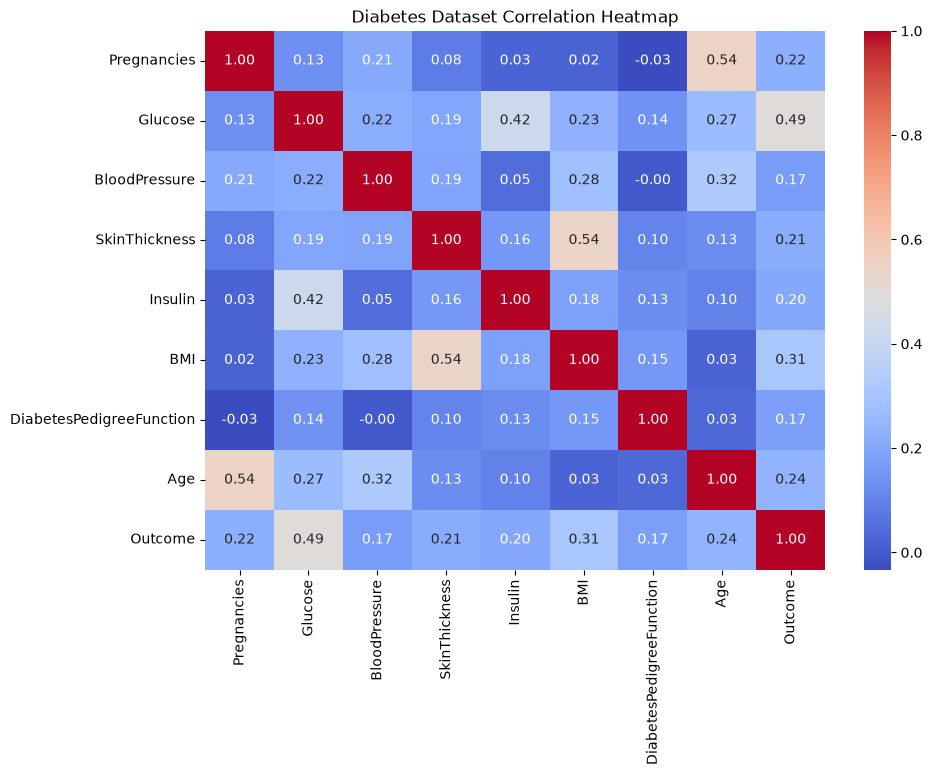

In [100]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Diabetes Dataset Correlation Heatmap")
plt.show()


# 17. Input and Output Variables

- `X` = input
- `y` = output


In [101]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Outcome")


Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


# 18. Train-Test Split

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 614
Testing rows: 154


# 19. Linear Regression

Linear Regression is included here to match the class exercise in the uploaded example.

Because `Outcome` is a binary target (0 or 1), Linear Regression is not the ideal classification model. We will still run it for learning purposes and round its predictions to 0 or 1.


In [103]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

# Convert continuous predictions into 0 or 1
linear_class_predictions = (linear_predictions >= 0.5).astype(int)

print("First 10 Linear Regression predictions:")
print(linear_predictions[:10])

print("\nFirst 10 rounded predictions:")
print(linear_class_predictions[:10])


First 10 Linear Regression predictions:
[ 0.58142648  0.14514265  0.34886061  0.31093668 -0.07655105  0.22493902
  0.4657553   0.93496166  0.09376088  0.76007621]

First 10 rounded predictions:
[1 0 0 0 0 0 0 1 0 1]


## 20. Linear Regression Evaluation

In [104]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)
linear_accuracy = accuracy_score(y_test, linear_class_predictions)

print("Linear Regression Results")
print("-------------------------")
print("Mean Absolute Error:", linear_mae)
print("Mean Squared Error:", linear_mse)
print("R2 Score:", linear_r2)
print("Accuracy after rounding:", linear_accuracy)


Linear Regression Results
-------------------------
Mean Absolute Error: 0.33446202199147246
Mean Squared Error: 0.17169709906531944
R2 Score: 0.24593177751238604
Accuracy after rounding: 0.7012987012987013


# 21. Decision Tree Classification

In [105]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

tree_predictions = decision_tree.predict(X_test)

print("First 10 Decision Tree predictions:")
print(tree_predictions[:10])


First 10 Decision Tree predictions:
[1 0 0 1 0 0 0 1 0 1]


## 22. Decision Tree Evaluation

In [106]:
tree_accuracy = accuracy_score(y_test, tree_predictions)

print("Decision Tree Accuracy:", tree_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, tree_predictions))


Decision Tree Accuracy: 0.7597402597402597

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       100
           1       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



## 23. Decision Tree Confusion Matrix

Confusion Matrix:
[[78 22]
 [15 39]]


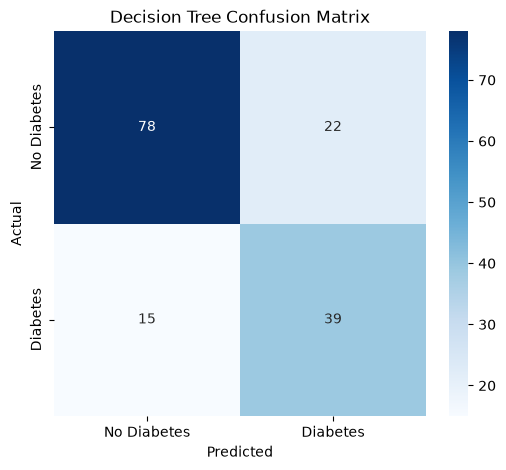

In [107]:
cm = confusion_matrix(y_test, tree_predictions)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()


## 24. Visualize the Decision Tree

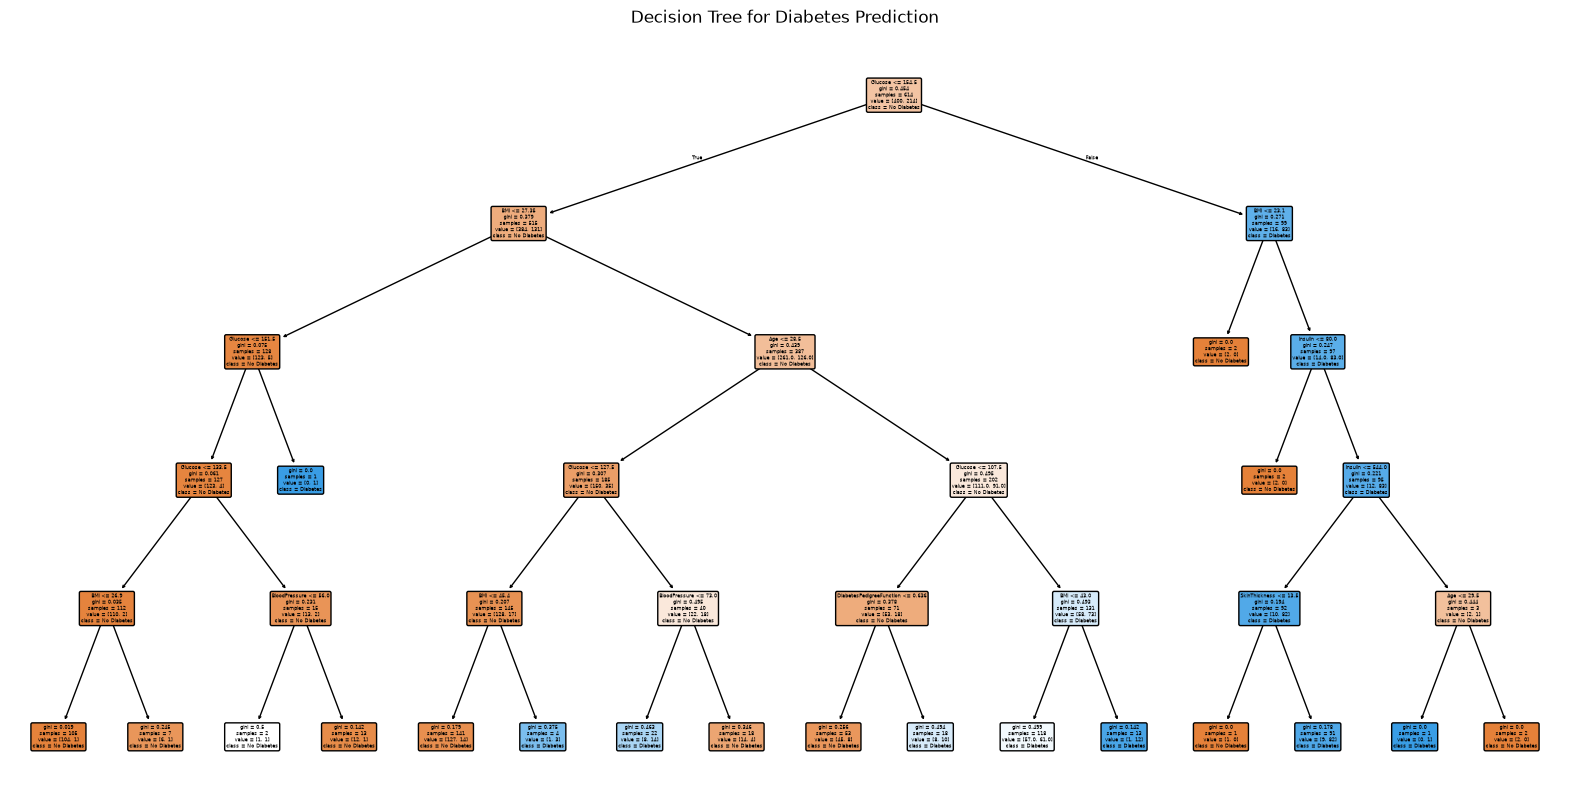

In [108]:
plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Diabetes Prediction")
plt.show()


# 25. Compare the Models

In [109]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "Accuracy": [linear_accuracy, tree_accuracy]
})

print(model_comparison)


               Model  Accuracy
0  Linear Regression  0.701299
1      Decision Tree  0.759740
